# Calidad de datos: nulos, duplicados y outliers

## Introduccion

Esta es una continuacion del notebook ``1.0--initial_data_exploration.ipynb`` en donde ya se pudo observar algunos puntos claves del dataset como:

- El dataset no presenta valores nulos NA ni valores nulos disfrazados como valores con 0 que no tengan sentido
- El dataset no presenta valores duplicados, al usar la libreria **ydata-profiling** pudimos observar esto.

Lo que se buscara entonces hacer en este notebook es el analisis de outliers ya que vimos presencia de estos en el target **salary**


### 1. Librerias e importacion del dataset

In [2]:
import pandas as pd
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Tipos de columnas
from salarlens_predictor.config import NUMERIC_COLS, CATEGORICAL_COLS, ORDINAL_COLS

2026-04-12 20:14:29.788 | INFO     | salarlens_predictor.config:<module>:11 - PROJ_ROOT path is: E:\ROAD_TO_DATA_SCIENCE\proyectos_programacion\python\SALARYLENS\SalaryLens-Predictor-de-Retorno-Laboral-con-Machine-Learning


In [3]:
NUMERIC_COLS

['experience_years', 'skills_count', 'certifications', 'salary']

In [4]:
ruta = pathlib.Path(r"E:\ROAD_TO_DATA_SCIENCE\proyectos_programacion\python\SALARYLENS\SalaryLens-Predictor-de-Retorno-Laboral-con-Machine-Learning\data\raw\job_salary_prediction_dataset.csv")

match ruta.exists():
    case True:
        print("Dataset encontrado correctamente en la ruta, leyendo datos...")
        df = pd.read_csv(ruta)
        display(df.head(10))
    case False:
        print("Dataset no encontrado en la ruta establecida.")

Dataset encontrado correctamente en la ruta, leyendo datos...


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
5,AI Engineer,0,High School,4,Education,Enterprise,USA,No,2,180351
6,Backend Developer,6,High School,16,Manufacturing,Enterprise,Canada,No,3,165375
7,Machine Learning Engineer,4,Bachelor,18,Healthcare,Enterprise,Canada,Hybrid,5,202463
8,AI Engineer,5,Diploma,14,Telecom,Enterprise,Singapore,Yes,0,171834
9,Frontend Developer,18,PhD,2,Retail,Enterprise,India,Hybrid,5,128377


### 2. Analisis de outliers

#### 2.1. Limites y numero de outliers

In [5]:
outliers_limites = []


# Calculamos el IQR de las columnas numericas

for key in NUMERIC_COLS:
    
    # calculo de iqr
    q1, q3 = np.percentile(df[key], [25,75])
    iqr = q3-q1 # Rango intercuartil

    # calculamos el rango de decision (fuera de este cualquier valor se considerara outlier)
    
    limite_inf = q1 - 1.5 * iqr
    if limite_inf < 0:
        limite_inf = 0
    limite_sup = q3 + 1.5 * iqr

    # Contamos el numero de outliers
    # Valores demasiado bajos
    outliers_bajos = (df[key] < limite_inf).sum()

    # Valores demasiado altos (si tienes un limite_sup)
    outliers_altos = (df[key] > limite_sup).sum()

    # Almacenamos los valores en un diccionario

    outliers_limites.append(
        {
            "feature" : key,
            "iqr" : iqr,
            "limite_inferior" : limite_inf,
            "limite_superior" : limite_sup,
            "outliers_bajos" : outliers_bajos,
            "outliers_altos" : outliers_altos
        }
    )

# Almacenamos la lista de diccionarios en formato DataFrame de pandas
pd.DataFrame(outliers_limites)


,feature,iqr,limite_inferior,limite_superior,outliers_bajos,outliers_altos
0,experience_years,10.0,0.0,30.0,0,0
1,skills_count,10.0,0.0,30.0,0,0
2,certifications,3.0,0.0,8.5,0,0
3,salary,50134.0,44157.0,244693.0,26,2310


Puede causar problemas el que los valores de limites inferiores esten en negativo, asi que se pondra como limite el 0, en realidad el que aparezcan en valores negativos es porque el calculo matematico lo hace asi, pero sabemos que en este caso el limite de los valores inferiores en cualquiera de los casos es 0

#### 2.2. Visualizacion de outliers usando Boxplots

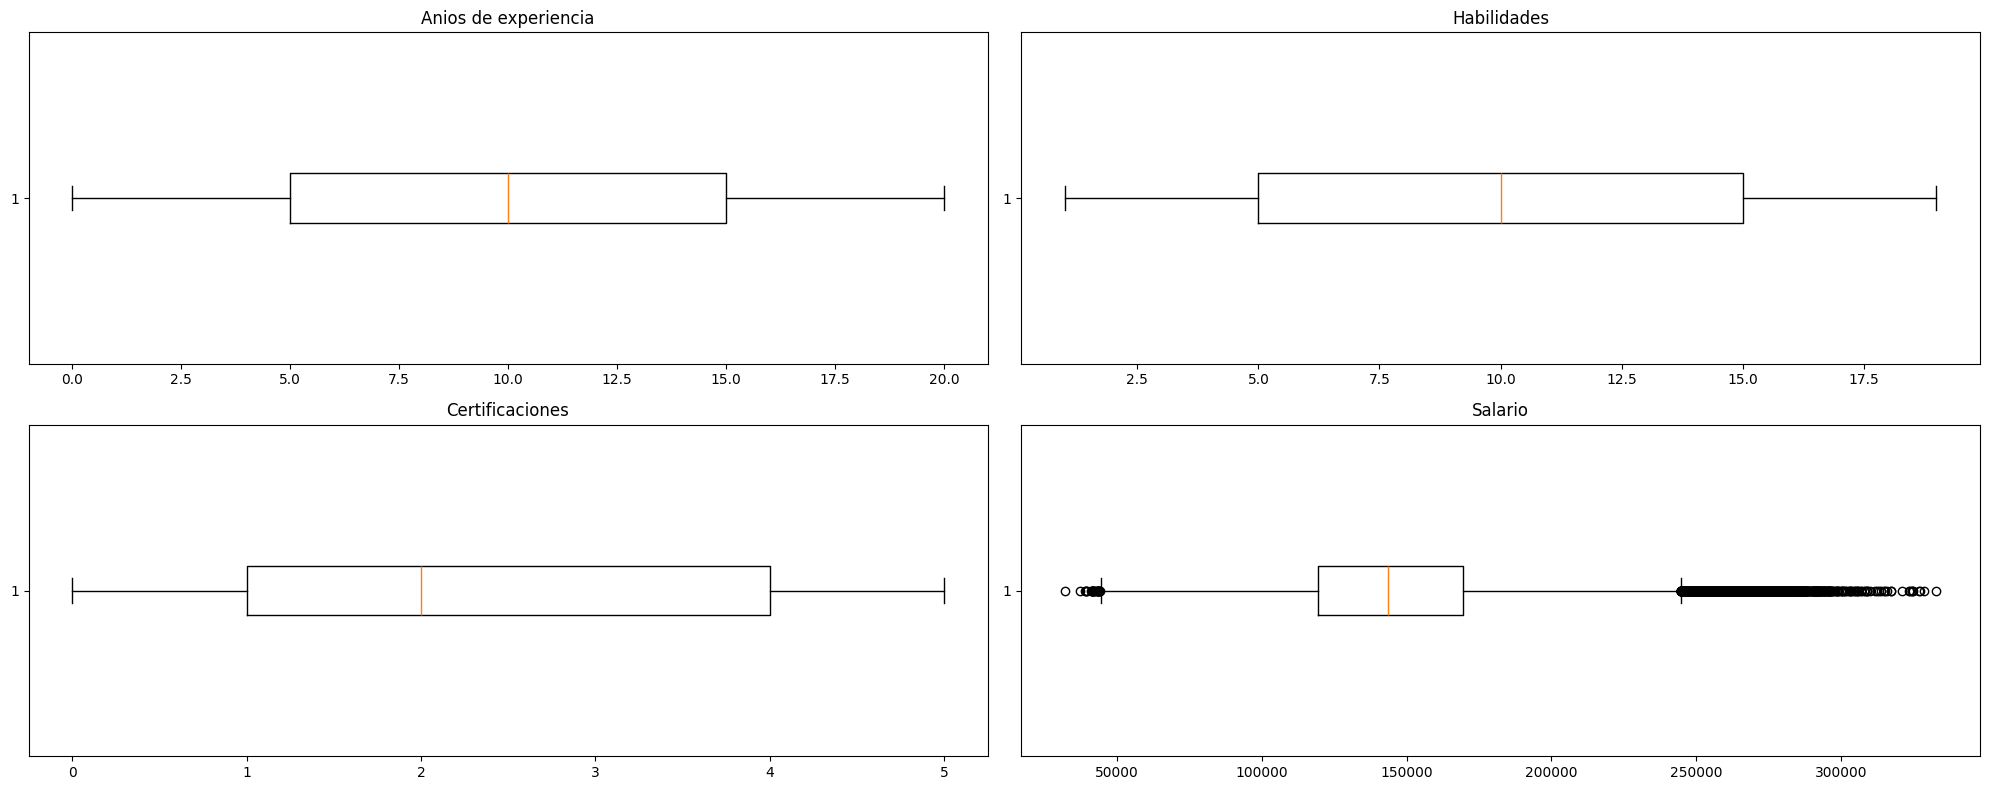

In [6]:
fig, ax = plt.subplots(2,2, figsize=(20,8))

# Feature: anios de experiencia
ax[0, 0].boxplot(df["experience_years"], vert=False)
ax[0, 0].set_title("Anios de experiencia")

# Feature: numero de habilidades
ax[0, 1].boxplot(df["skills_count"], vert=False)
ax[0, 1].set_title("Habilidades")
# Feature: numero de certificaciones
ax[1, 0].boxplot(df["certifications"], vert=False)
ax[1, 0].set_title("Certificaciones")
# Feature: salary
ax[1, 1].boxplot(df["salary"], vert=False)
ax[1, 1].set_title("Salario")

plt.tight_layout() # Evita que se solapen los títulos
plt.show()


### 3. Visualizacion de distribucion de salary

<Axes: >

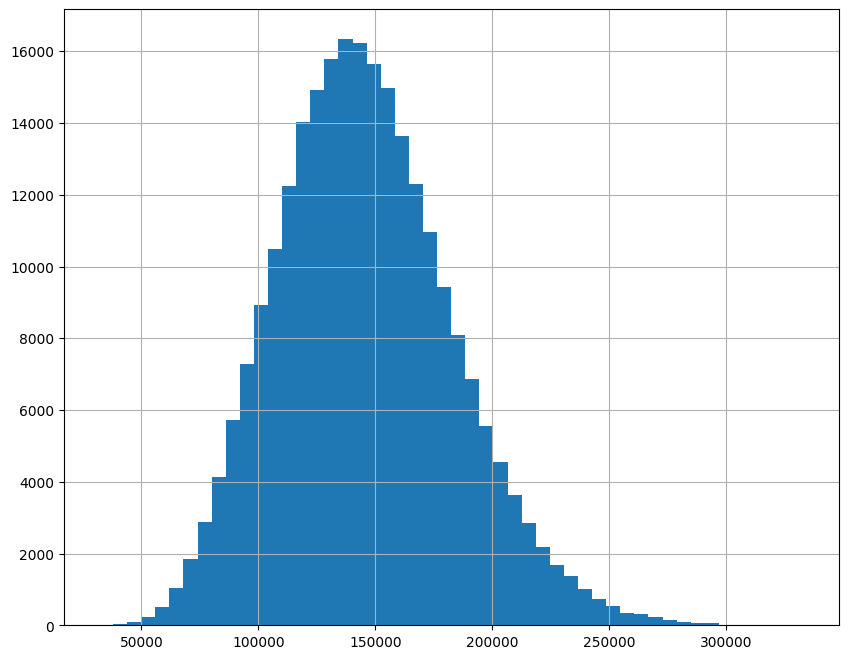

In [7]:
df["salary"].hist(bins=50, figsize=[10,8])

#### Decision fundamentada

La variable objetivo ``salary`` presenta una asimetria positiva (hacia la derecha) de nivel leve a moderado, caracterizada por la presencia de valores atipicos significativamente superiores a la media. Para mitigar este sesgo, se ha optado por aplicar una transformacion matematica con el fin de alcanzar los siguientes objetivos:

- **Normalizacion de la distribucion:** Aproximar el comportamiento del target a una distribucion Gaussiana.
- **Optimizacion del escalado:** Facilitar la aplicacion de tecnicas de feature scaling, ya que la mayoria de algoritmos de aprendizaje automatico convergen de manera mas eficiente cuando los datos presentan una distribucion normal.

**Seleccion de la transformacion: Raiz cuadrada vs Logaritmica**

Ambas tecnicas buscan reducir la magnitud de los valores mas altos en mayor proporcion que los valores bajos. Sin embargo, la eleccion depende de la intensidad del sesgo:

1. **Transformacion Logaritmica:** Ejerce una "penalizacion" mas agresiva sobre los valores mas grandes. Es la opcion ideal para distribuciones con cola pesada (Power law), donde el sesgo es extremo.
2. **Transformacion por Raiz cuadrada:** Es nas moderada. Reduce la varianza de los valores altos sin comprimir la distribucion de forma tan drastica como el logaritmo

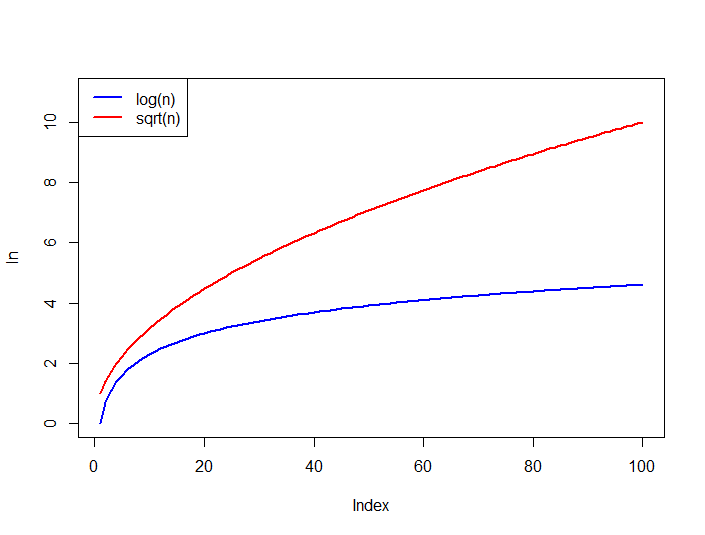

**Decision tecnica:**

Dado que el conjunto de datos no presenta una distribucion de cola pesada, sino un **sesgo moderado**, la transformacion logaritmica resultaria demasiado fuerte para nuestros objetivos. En su lugar, se aplicara la **raiz cuadrada**, que permite corregir la asimetria de forma equilibrada sin perder la sensibilidad necesaria en los datos de mayor magnitud.

#### Aplicando la transformacion

In [18]:
# Creamos una instancia de nuestro dataset para no alterar el original
cleaned_df = df.copy()

In [21]:
cleaned_df["salary_sqrt"] = cleaned_df["salary"].pow(0.5)
cleaned_df["salary_log"] = cleaned_df["salary"].transform("log")

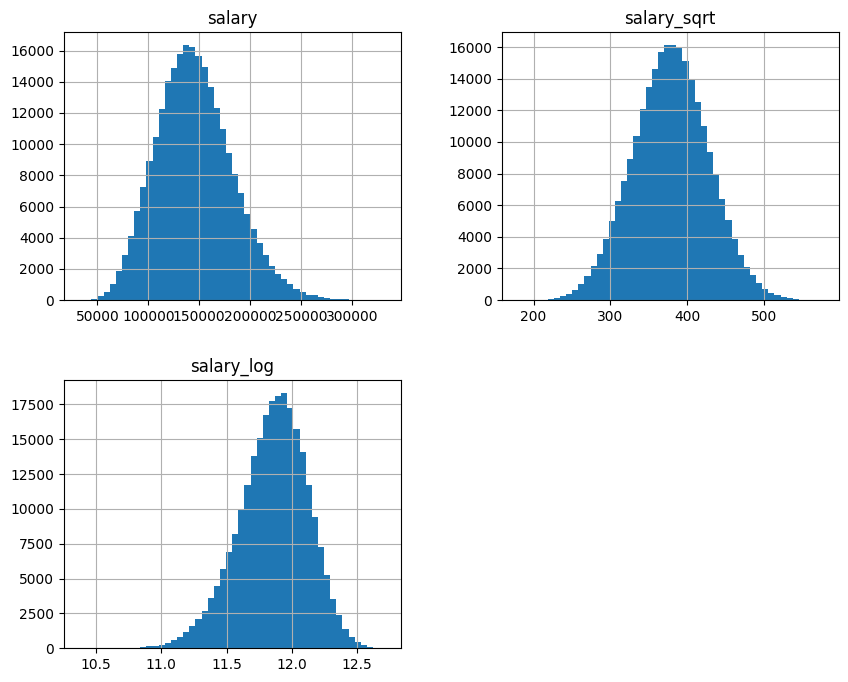

In [22]:
cleaned_df[
    ["salary", "salary_sqrt", "salary_log"]
].hist(bins=50, figsize=[10,8])

plt.show()

In [26]:
# Eliminamos la columna salary ya que es la que es la que se encontraba sesgada y salary_log ya que la utilizamos solo para visualizar que camino tomar
cleaned_df.drop(columns=['salary_log', 'salary'], axis=1)

# Transformamos el dataframe de pandas a csv y lo almacenamos en data/interim
cleaned_df.to_csv(r"E:\ROAD_TO_DATA_SCIENCE\proyectos_programacion\python\SALARYLENS\SalaryLens-Predictor-de-Retorno-Laboral-con-Machine-Learning\data\interim/cleaned_df.csv", index=False, encoding="utf-8")

#### Resumen del preprocesamiento de datos

- **Transformacion del target:** Se aplico una transformacion de **raiz cuadrada** a la variable ``salary``. Esta tecnica permitio corregir la asimetria positiva y aproximar la feature a una distribucion normal, optimizando su comportamiento para futuros algoritmos de aprendizaje.
- **Tratamiento de outliers:** Tras el analisis, se confirmo que las variables independientes (features) no presentan valores atipicos significativos que comprometan la integridad del mdoelo.
- **Integridad del dataset:** El conjunto de datos se encuentra **completamente limpio**, sin valores nulos ni inconsistencias. El dataset esta listo para la fase de **Analisis univariante** y modelado.
- **Gestion de archivos:** 
    - El dataset procesado sera exportado a ``data/interim/cleaned_data.csv``.
    - La justificacion tecnica de las transformaciones y el registro de cambios se encuentran documentados en: ``references/data_cleaning_decisions.md``.